In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [24]:
df = pd.read_csv("df_india.csv")

In [70]:
sir_df = df[
    [
        'date',
        'total_cases',
        'new_cases',
        'new_cases_smoothed',
        'total_deaths'
    ]
].copy()



In [71]:
sir_df['date'] = pd.to_datetime(sir_df['date'])

sir_df = sir_df.sort_values('date').reset_index(drop=True)

Need numerical time for ODE solver

In [72]:
sir_df['t'] = (
    sir_df['date'] - sir_df['date'].min()
).dt.days

sir_df[['date', 't']].head()

,date,t
0,2020-01-30,0
1,2020-01-31,1
2,2020-02-01,2
3,2020-02-02,3
4,2020-02-03,4


For SIR Model, we will take all the assumptions as mentioned in the theory

In [73]:
N = 1_400_000_000

I0 = sir_df['total_cases'].iloc[0] 

R0 = 0

S0 = N - I0 - R0

print("Population:", N)
print("S0:", S0)
print("I0:", I0)
print("R0:", R0)
print("Check:", S0 + I0 + R0)

Population: 1400000000
S0: 1399999999.0
I0: 1.0
R0: 0
Check: 1400000000.0


In [74]:
def sir_model(t, y, beta, gamma, N):

    S, I, R = y

    dSdt = -beta * S * I / N

    dIdt = beta * S * I / N - gamma * I

    dRdt = gamma * I

    return [dSdt, dIdt, dRdt]

In [75]:
beta_test = 0.3
gamma_test = 0.1

In [76]:
solution = solve_ivp(
    sir_model,
    [sir_df['t'].min(), sir_df['t'].max()],
    [S0, I0, R0],
    args=(beta_test, gamma_test, N),
    t_eval=sir_df['t']
)

In [77]:
S = solution.y[0]
I = solution.y[1]
R = solution.y[2]

In [78]:
sir_simulated = pd.DataFrame({
    'date': sir_df['date'],
    'S': S,
    'I': I,
    'R': R
})

In [79]:
sir_simulated.head()

,date,S,I,R
0,2020-01-30,1.400000e+09,1.000000,0.000000
1,2020-01-31,1.400000e+09,1.221403,0.110701
2,2020-02-01,1.400000e+09,1.491847,0.245924
3,2020-02-02,1.400000e+09,1.822168,0.411084
4,2020-02-03,1.400000e+09,2.225493,0.612747


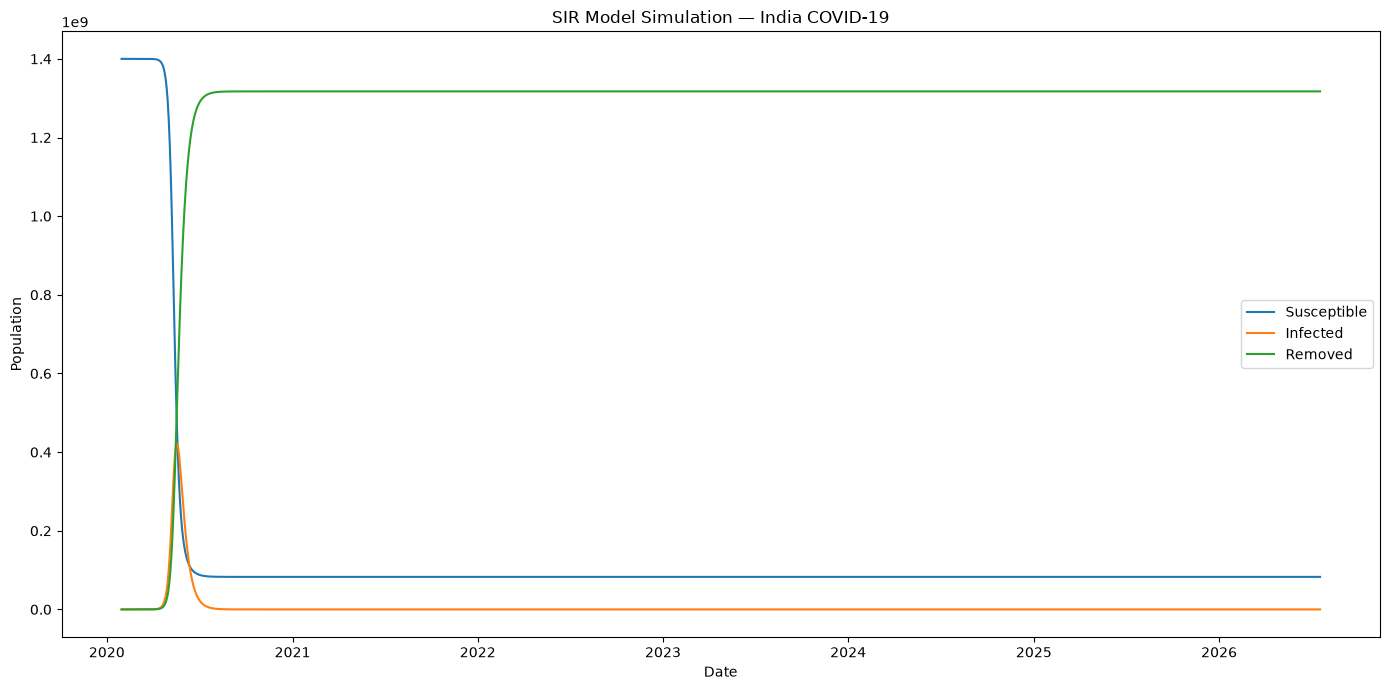

In [80]:
plt.figure(figsize=(14, 7))

plt.plot(
    sir_simulated['date'],
    sir_simulated['S'],
    label='Susceptible'
)

plt.plot(
    sir_simulated['date'],
    sir_simulated['I'],
    label='Infected'
)

plt.plot(
    sir_simulated['date'],
    sir_simulated['R'],
    label='Removed'
)

plt.xlabel('Date')
plt.ylabel('Population')
plt.title('SIR Model Simulation — India COVID-19')

plt.legend()
plt.tight_layout()
plt.show()

New parameter estimation 

In [41]:
def simulate_sir(params, t, N, S0, I0, R0):

    beta, gamma = params

    solution = solve_ivp(
        sir_model,
        [t.min(), t.max()],
        [S0, I0, R0],
        args=(beta, gamma, N),
        t_eval=t
    )

    return solution.y

residual function

In [42]:
def residuals(params, t, observed_cases, N, S0, I0, R0):

    S, I, R = simulate_sir(
        params,
        t,
        N,
        S0,
        I0,
        R0
    )

    return I - observed_cases

predicted new infections

In [43]:
def simulate_sir(params, t, N, S0, I0, R0):

    beta, gamma = params

    solution = solve_ivp(
        sir_model,
        [t.min(), t.max()],
        [S0, I0, R0],
        args=(beta, gamma, N),
        t_eval=t
    )

    S = solution.y[0]
    I = solution.y[1]
    R = solution.y[2]

    new_infections = beta * S * I / N

    return S, I, R, new_infections

update residual func

In [44]:
def residuals(
    params,
    t,
    observed_cases,
    N,
    S0,
    I0,
    R0
):

    S, I, R, new_infections = simulate_sir(
        params,
        t,
        N,
        S0,
        I0,
        R0
    )

    return new_infections - observed_cases

estimate updated paramaters

In [46]:
initial_params = [
    0.3,   # beta
    0.1    # gamma
] 

result = least_squares(
    residuals,
    initial_params,
    bounds=(
        [0.0001, 0.0001],
        [5.0, 1.0]
    ),
    args=(
        sir_df['t'].values,
        sir_df['new_cases_smoothed'].values,
        N,
        S0,
        I0,
        R0
    )
) 

beta_estimated = result.x[0]
gamma_estimated = result.x[1]

print("Estimated beta:", beta_estimated)
print("Estimated gamma:", gamma_estimated)

Estimated beta: 1.0295162401802567
Estimated gamma: 0.9999999999999999


In [47]:
R0_estimated = beta_estimated / gamma_estimated

print("Estimated R0:", R0_estimated)

Estimated R0: 1.029516240180257


Generate the fitted SIR trajectory

In [48]:
S_fit, I_fit, R_fit, predicted_cases = simulate_sir(
    result.x,
    sir_df['t'].values,
    N,
    S0,
    I0,
    R0
)

sir_df['predicted_cases'] = predicted_cases

Updated Plot

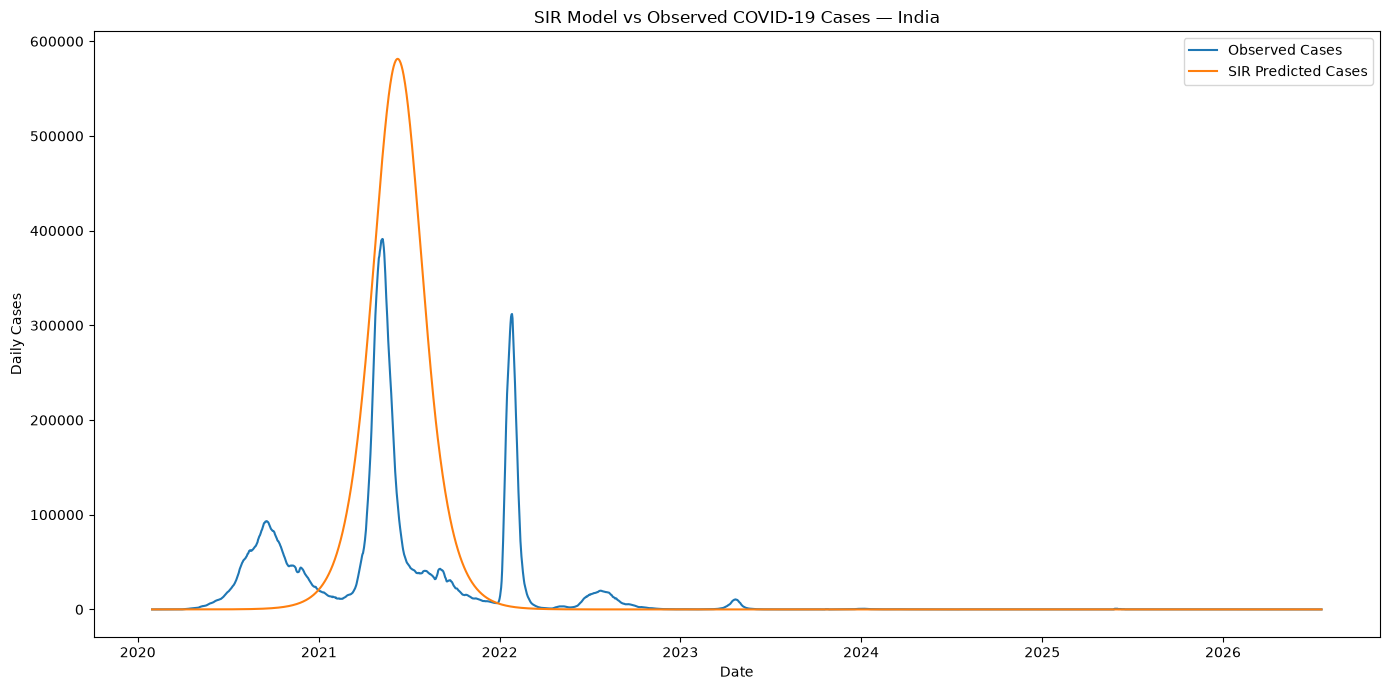

In [50]:
plt.figure(figsize=(14, 7))

plt.plot(
    sir_df['date'],
    sir_df['new_cases_smoothed'],
    label='Observed Cases'
)

plt.plot(
    sir_df['date'],
    sir_df['predicted_cases'],
    label='SIR Predicted Cases'
)

plt.xlabel('Date')
plt.ylabel('Daily Cases')
plt.title('SIR Model vs Observed COVID-19 Cases — India')

plt.legend()

plt.tight_layout()
plt.show()